This notebook is used for the creation of model boundary conditions for the North Atlantic model. Just as for the initial condition, the boundary condition vector quantities need to rotated on the curvilinear model domain. 

First, import packages necessary for this notebook:

In [20]:
# import the modules for computation, plotting, and reading files
import os
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc4
#import cmocean.cm as cm
from datetime import datetime
import ast

# import the necessary modules from eccoseas
from eccoseas.ecco import io
from eccoseas.ecco import grid as eeg
from eccoseas.downscale import hFac
from eccoseas.downscale import horizontal
from eccoseas.downscale import vertical

## Constructing the Boundary Conditions
For this model, we will use a model state from the ECCO Version 5 state estimate. We will prepare the boundary condition fields in 7 steps:
1. download the ECCO model output
2. read the ECCO model grid
3. read in the bathymetry for the regional model as well as its grid
4. prepare the ECCO fields for interpolation
5. interpolate the ECCO fields onto the regional model grid and store each as a binary file
6. plot the interpolated fields to ensure they look as expected
7. create an additional field for 1991

### Step 1: Run ECCO with dv
Details

There are stored in the following directory:

In [21]:
data_folder = '/Users/mhwood/Documents/Research/Projects/Chukchi_Sea/Data/Model Setup Files'

### Step 3: Read in the Model Grid and Generate a Mask
Here, I will recreate the grid I will use in my model and read in the bathymetry file (see previous notebooks for details):

In [22]:
# define the input directory (see previous notebook for details)
input_dir = '/Users/mhwood/Documents/Research/Projects/Chukchi_Sea/Model/input'

In [23]:
# define the parameters that will be used in the data file
ds = nc4.Dataset(os.path.join(data_folder,'Chukchi_Sea_grid.nc'))
XC = ds.variables['XC'][:, :]
YC = ds.variables['YC'][:, :]
bathy = -1*ds.variables['Depth'][:,:]
AngleCS = ds.variables['AngleCS'][:,:]
AngleSN = ds.variables['AngleSN'][:,:]
hFacC = ds.variables['HFacC'][:, :, :]
hFacW = ds.variables['HFacW'][:, :, :]
hFacS = ds.variables['HFacS'][:, :, :]
delR = ds.variables['drF'][:]
dxG = ds.variables['dxG'][:, :]
dyG = ds.variables['dyG'][:, :]
ds.close()

# remove the extra row and col from hFacS and hFacW
hFacS = hFacS[:,:-1,:]
hFacW = hFacW[:,:,:-1]

Nr = len(delR)

### Step 2: Read in the ECCO grid
To read in the ECCO fields, we will rely on the `io` module from the `eccoseas.ecco` package:

In [24]:
ecco_XC_faces, ecco_YC_faces, ecco_AngleCS_faces, ecco_AngleSN_faces, ecco_hFacC_faces, ecco_hFacW_faces, ecco_hFacS_faces =\
     io.read_ecco_geometry_to_faces(data_folder, llc=270, Nr=50)

In [25]:
ecco_XC_tiles = eeg.ecco_faces_to_tiles(ecco_XC_faces, llc=270, dim=2)
ecco_YC_tiles = eeg.ecco_faces_to_tiles(ecco_YC_faces, llc=270, dim=2)
ecco_AngleCS_tiles = eeg.ecco_faces_to_tiles(ecco_AngleCS_faces, llc=270, dim=2)
ecco_AngleSN_tiles = eeg.ecco_faces_to_tiles(ecco_AngleSN_faces, llc=270, dim=2)
ecco_hFacC_tiles = eeg.ecco_faces_to_tiles(ecco_hFacC_faces, llc=270, dim=3)
ecco_hFacS_tiles = eeg.ecco_faces_to_tiles(ecco_hFacS_faces, llc=270, dim=3)
ecco_hFacW_tiles = eeg.ecco_faces_to_tiles(ecco_hFacW_faces, llc=270, dim=3)
ecco_RF = np.fromfile(os.path.join(data_folder,'RF.data'), '>f4')
ecco_DRF = np.fromfile(os.path.join(data_folder,'DRF.data'), '>f4')

In [26]:
ecco_Nr = np.size(ecco_DRF)

As in the initial condition notebook, we will make masks by setting all of the non-zero `hFac` points to 1:

In [27]:
# generate the masks
maskC = np.copy(hFacC)
maskC[maskC>0] = 1

maskS = np.copy(hFacS)
maskS[maskS>0] = 1

maskW = np.copy(hFacW)
maskW[maskW>0] = 1

### Step 4: Prepare the grids for interpolation

Next, we read in points from just the tiles overlapping out domain to use in interpolation:

Note that in the previous notebook, we have already identified tiles 7 and 8 as those pertaining to the regional domain.

In [28]:
# define the tile list
tile_list = [7,8]

In [29]:
# determine the number of points in each set
total_points = 0
for tile_number in tile_list:
    total_points += np.size(ecco_XC_tiles[tile_number])

# make empty arrays to fill in
ecco_XC_points = np.zeros((total_points, ))
ecco_YC_points = np.zeros((total_points, ))
ecco_AngleCS_points = np.zeros((total_points, ))
ecco_AngleSN_points = np.zeros((total_points, ))
ecco_maskC_points = np.zeros((ecco_Nr, total_points))
ecco_maskW_points = np.zeros((ecco_Nr, total_points))
ecco_maskS_points = np.zeros((ecco_Nr, total_points))
ecco_hFacW_points = np.zeros((ecco_Nr, total_points))
ecco_hFacS_points = np.zeros((ecco_Nr, total_points))

# loop through the tiles and fill in the XC, YC, and mask points for interpolation
points_counted = 0
for tile_number in tile_list:
    tile_N = np.size(ecco_XC_tiles[tile_number])
    
    ecco_XC_points[points_counted:points_counted+tile_N] = ecco_XC_tiles[tile_number].ravel()
    ecco_YC_points[points_counted:points_counted+tile_N] = ecco_YC_tiles[tile_number].ravel()

    ecco_AngleCS_points[points_counted:points_counted+tile_N] = ecco_AngleCS_tiles[tile_number].ravel()
    ecco_AngleSN_points[points_counted:points_counted+tile_N] = ecco_AngleSN_tiles[tile_number].ravel()
    
    for k in range(ecco_Nr):
        level_hFacC = ecco_hFacC_tiles[tile_number][k, :, :]
        if tile_number<7:
            level_hFacW = ecco_hFacW_tiles[tile_number][k, :, :]
            level_hFacS = ecco_hFacS_tiles[tile_number][k, :, :]
        else:
            level_hFacS = ecco_hFacW_tiles[tile_number][k, :, :] # these are switched due to the 
            level_hFacW = ecco_hFacS_tiles[tile_number][k, :, :] # assumptions about velocity - see note below
        ecco_hFacW_points[k, points_counted:points_counted+tile_N] = level_hFacW.ravel()
        ecco_hFacS_points[k, points_counted:points_counted+tile_N] = level_hFacS.ravel()
        level_maskC = np.copy(level_hFacC)
        level_maskC[level_maskC>0] = 1
        level_maskW = np.copy(level_hFacW)
        level_maskW[level_maskW>0] = 1
        level_maskS = np.copy(level_hFacS)
        level_maskS[level_maskS>0] = 1
        ecco_maskC_points[k, points_counted:points_counted+tile_N] = level_maskC.ravel()
        ecco_maskW_points[k, points_counted:points_counted+tile_N] = level_maskW.ravel()
        ecco_maskS_points[k, points_counted:points_counted+tile_N] = level_maskS.ravel()
    
    points_counted += tile_N

# wrap the longitude points
ecco_XC_points[ecco_XC_points<0] += 360

# remove the points outside the immediate area
local_indices = (ecco_XC_points<250) & (ecco_XC_points>120) & (ecco_YC_points>55) & (ecco_YC_points<80)
ecco_maskC_points = ecco_maskC_points[:, local_indices]
ecco_maskW_points = ecco_maskW_points[:, local_indices]
ecco_maskS_points = ecco_maskS_points[:, local_indices]
ecco_hFacW_points = ecco_hFacW_points[:, local_indices]
ecco_hFacS_points = ecco_hFacS_points[:, local_indices]
ecco_YC_points = ecco_YC_points[local_indices]
ecco_XC_points = ecco_XC_points[local_indices]

## Make a BC Reference File

In [30]:
# add all the following functions to a module

In [31]:
def elapsed_seconds_to_iters(start_seconds, seconds_per_iter, elapsed_seconds):
    iter_numbers = int((elapsed_seconds-start_seconds)/seconds_per_iter)
    return(iter_numbers)

def find_dv_files_to_read(config_dir, L1_model_name, boundary, var_name, averaging_period, seconds_per_iter, points_per_output, Nr):

    iters_per_output = averaging_period/seconds_per_iter

    # loop through the dv files and mask a list of how many fields each file has
    file_names = []
    file_iters = []
    n_files_in_files = []
    dv_dir = os.path.join(config_dir, 'L0','run', 'dv',L1_model_name)#'L1_'+boundary)
    tmp_counter = 0
    for file_name in os.listdir(dv_dir):
        if L1_model_name in file_name and var_name in file_name and boundary in file_name:
            file_iter = int(file_name.split('.')[-2])
            iters_per_file = int(np.size(np.fromfile(os.path.join(dv_dir,file_name),'>f4'))/(points_per_output*Nr))
            file_iters.append(file_iter)
            file_names.append(file_name)
            n_files_in_files.append(iters_per_file)
            tmp_counter+=1

    # sort the lists in case they got out of whack
    sorted_indices = sorted(range(len(file_iters)), key=lambda k: file_iters[k])
    file_names_sorted = []
    file_iters_sorted = []
    n_files_in_files_sorted = []
    for index in sorted_indices:
        file_names_sorted.append(file_names[index])
        file_iters_sorted.append(file_iters[index])
        n_files_in_files_sorted.append(n_files_in_files[index])

    # make dicts of the index and corresponding iters (w.r.t the parent model) which cen be read from these files
    iter_midpoint_dict = {}
    for i in range(len(file_iters_sorted)):
        file_iter = file_iters_sorted[i]

        # there's some funky business with indexing at the start of the model - this seems to fix it
        if file_iter == 2:
            file_iter -= 1

        file_name = file_names_sorted[i]
        iters_per_file = n_files_in_files_sorted[i]

        file_endpoints = np.arange(file_iter - 1, file_iter - 1 + (iters_per_file + 1) * iters_per_output, iters_per_output)
        file_midpoints = file_endpoints[:-1] + np.diff(file_endpoints) / 2

        iter_midpoint_dict[file_name] = file_midpoints

    return(file_names, iter_midpoint_dict)

def create_destination_file_list(config_dir, var_name, file_names, iter_midpoint_dict, averaging_period, seconds_per_iter, print_level=5):

    start_seconds = 0
    iters_per_output = averaging_period / seconds_per_iter

    # create a list of daily bounds
    date_bounds = []
    for year in range(2022,2025):
        for month in range(1, 13):
            if month in [1, 3, 5, 7, 8, 10, 12]:
                nDays = 31
            elif month in [4, 6, 9, 11]:
                nDays = 30
            else:
                if year % 4 == 0:
                    nDays = 29
                else:
                    nDays = 28
            if month==12:
                date_bounds.append([datetime(year, month, 1), datetime(year+1, 1, 1)])
            else:
                date_bounds.append([datetime(year, month, 1), datetime(year, month+1, 1)])
        #     for day in range(1, nDays):
        #         date_bounds.append([datetime(year, month, day), datetime(year, month, day + 1)])
        #     if month != 12:
        #         date_bounds.append([datetime(year, month, day + 1), datetime(year, month + 1, 1)])
        # date_bounds.append([datetime(year, 12, 31), datetime(year + 1, 1, 1)])

    dest_files = []
    dest_file_iter_bounds = {}
    # convert these to iteration numbers
    for date_set in date_bounds:
        date_0 = (date_set[0] - datetime(1992, 1, 1)).total_seconds()
        date_1 = (date_set[1] - datetime(1992, 1, 1)).total_seconds()
        iter_0 = elapsed_seconds_to_iters(start_seconds, seconds_per_iter, date_0)
        iter_1 = elapsed_seconds_to_iters(start_seconds, seconds_per_iter, date_1)
        dest_file = 'L1_BC_'+str(var_name)+'.'+str(date_set[0].year)+'{:02d}'.format(date_set[0].month)+'.bin'
        dest_files.append(dest_file)
        dest_file_iter_bounds[dest_file] = [iter_0,iter_1]

    source_file_read_dict = {}
    source_file_read_index_sets = {}

    # # make dicts of the index and corresponding iters which will be read from these files
    for dest_file in dest_files:
        if print_level>=5:
            print('               - Creating reference dictionary for '+dest_file)

        source_file_read_dict[dest_file] = []
        source_file_read_index_sets[dest_file] = []

        dest_file_iter_0 = dest_file_iter_bounds[dest_file][0]
        dest_file_iter_1 = dest_file_iter_bounds[dest_file][1]
        if print_level>=5:
            print('                   - This file will cover iterations with start points '+str(dest_file_iter_0)+' to '+str(dest_file_iter_1))

        dest_file_iters = np.arange(dest_file_iter_0,dest_file_iter_1,iters_per_output)
        dest_file_iters += iters_per_output / 2
        if print_level >= 5:
            print('                   - This file will cover iterations with midpoints: '+str(np.min(dest_file_iters))+' to '+str(np.max(dest_file_iters)))

        source_file_names = []

        # get a list of files to use for each iteration
        for dest_iter in dest_file_iters:
            file_to_use = ''
            for file_name in file_names:
                iter_midpoints = iter_midpoint_dict[file_name]
                if dest_iter >= np.min(iter_midpoints) and dest_iter <= np.max(iter_midpoints):
                    if file_to_use == '':
                        file_to_use = file_name
                    else:
                        if int(file_to_use.split('.')[-2]) > int(file_name.split('.')[-2]):
                            file_to_use = file_name
            if file_to_use!='':
                source_file_names.append(file_to_use)

        if len(source_file_names)>0:

            # use the list of source file names to make a dict that lists which iters to read from it
            unique_list = list(set(source_file_names))
            if print_level >= 5:
                print('                    - Reading from file(s) '+', '.join(unique_list))
            for file_name in unique_list:
                source_file_read_dict[dest_file].append(file_name)
            source_file_read_dict[dest_file] = sorted(source_file_read_dict[dest_file])

            # loop through the source file names to identify which indices will be read from each one
            for file_name in source_file_read_dict[dest_file]:
                min_dest_iter_index = source_file_names.index(file_name)
                max_dest_iter_index = len(source_file_names) - 1 - source_file_names[::-1].index(file_name)
                min_dest_iter = dest_file_iters[min_dest_iter_index]
                max_dest_iter = dest_file_iters[max_dest_iter_index]
                print('        - The file ' + file_name+ ' will cover iters '+str(min_dest_iter)+' to '+str(max_dest_iter))
                source_file_iters = iter_midpoint_dict[file_name]
                # print(source_file_iters)
                if print_level >= 5:
                    print('                      - This file has iters '+str(np.min(source_file_iters))+' to '+str(np.max(source_file_iters))+' (n='+str(len(source_file_iters))+', step = '+str(source_file_iters[1]-source_file_iters[0])+')')
                # try:
                index_0 = list(source_file_iters).index(min_dest_iter)
                index_1 = list(source_file_iters).index(max_dest_iter)
                if index_1<len(source_file_iters)-1:
                    index_1 += 1
                if file_name == source_file_read_dict[dest_file][-1]:
                    index_1 -= 1

                # can't figure this out...
                if dest_file[-10:]=='202204.bin':
                    index_1+=1
                
                # # can't figure this out...
                # if dest_file[-10:] == '199708.bin':
                #     index_1 += 1

                # print('            - This corresponds to indices '+str(index_0)+' ('+str(source_file_iters[index_0]) +') through '+str(index_1-1)+' ('+str(source_file_iters[index_1-1]) +')')
                source_file_read_index_sets[dest_file].append([index_0, index_1])
                # except:
                #     a=1
                #     # print('            - Didnt find the correct indices in this file')


    return(dest_files, source_file_read_dict, source_file_read_index_sets)


In [32]:
config_dir = '/Users/mhwood/Documents/Research/Projects/Ocean_Modelling/Projects/Downscale_Greenland/'+\
          'MITgcm/configurations/downscale_greenland'

input_dir = '/Users/mhwood/Documents/Research/Projects/Chukchi_Sea/Model/input'

var_name = 'THETA'
boundary = 'north'

averaging_period = 86400
seconds_per_iter = 1200
L1_model_name = 'Chukchi_Sea'
print_level = 7


# first read how many points are expected in each iter (read from the mask reference)
mask_ref_file = os.path.join(config_dir, 'L0', 'input', 'L0_dv_mask_reference_dict.nc')
ds = nc4.Dataset(mask_ref_file)
points_per_output = len(ds.groups[L1_model_name+'_'+boundary].variables['source_rows'][:])
ds.close()

# calculate the file name iterations to read from
#     along with the iterations these files cover
file_names, iter_midpoint_dict = find_dv_files_to_read(config_dir, L1_model_name, boundary, var_name, averaging_period, seconds_per_iter, points_per_output, ecco_Nr)
file_names = sorted(file_names)

print('    - Source file summary:')
output = '{\n'
for file_name in file_names:
    print('        - The file ' + file_name + ' has iterations centered on ' + str(np.min(iter_midpoint_dict[file_name])) +
          ' to ' + str(np.max(iter_midpoint_dict[file_name]))+' ('+str(len(iter_midpoint_dict[file_name]))+')')
    output += ' \''+file_name.split('.')[-2]+'\': '+'['+str(np.min(iter_midpoint_dict[file_name]))+\
              ', '+str(np.max(iter_midpoint_dict[file_name]))+'],\n'
output += '}'

output_file = os.path.join(input_dir,L1_model_name+'_BC_source_ref.txt')
f = open(output_file,'w')
f.write(output)
f.close()

# calculate the destination file iteration bounds
#     along with the source files data they will contain, and which indices of those source files they will contain
dest_files, source_file_read_dict, source_file_read_index_sets = create_destination_file_list(config_dir, var_name, file_names,
                                                                                              iter_midpoint_dict, averaging_period, seconds_per_iter, print_level=2)

print('    - Destination file summary:')
output = '{\n'
for file_name in dest_files:
    print('        - The file ' + file_name + ' will be created from the following data:')
    output+=' \''+file_name.split('.')[-2]+'\': ['
    source_files = source_file_read_dict[file_name]
    index_sets = source_file_read_index_sets[file_name]
    iter_count = 0
    add_line = ''
    for s in range(len(source_files)):
        if len(index_sets)>0:
            if print_level >= 2:
                print('            - From ' + source_files[s] + ', will read indices ' + str(
                index_sets[s][0]) + ' though ' + str(index_sets[s][1]) + ' ('+str(index_sets[s][1] - index_sets[s][0] + 1)+')')
            iter_count += index_sets[s][1] - index_sets[s][0] + 1
            add_line += '[\'' + source_files[s].split('.')[-2] + '\', ' + '[' + str(index_sets[s][0]) + ', ' + str(index_sets[s][1]) + ']], '


    year = int(file_name.split('.')[1][:4])
    month = int(file_name.split('.')[1][4:6])
    if month in [1, 3, 5, 7, 8, 10, 12]:
        nDays = 31
    elif month in [4, 6, 9, 11]:
        nDays = 30
    else:
        if year % 4 == 0:
            nDays = 29
        else:
            nDays = 28

    if year == 2024 and month == 12:
        output += add_line[:-2]
    elif iter_count == nDays:
        output += add_line[:-2]
    else:
        output += ''
    if print_level >= 2:
        print('            - Total iterations for this file: '+str(iter_count)+' (check = '+str(nDays)+' days)')
    output+='],\n'
output += '}'

output_file = os.path.join(input_dir,L1_model_name+'_BC_dest_ref.txt')
f = open(output_file,'w')
f.write(output)
f.close()

    - Source file summary:
        - The file Chukchi_Sea_north_THETA.0000788977.bin has iterations centered on 789012.0 to 797580.0 (120)
        - The file Chukchi_Sea_north_THETA.0000797617.bin has iterations centered on 797652.0 to 806220.0 (120)
        - The file Chukchi_Sea_north_THETA.0000806257.bin has iterations centered on 806292.0 to 814860.0 (120)
        - The file Chukchi_Sea_north_THETA.0000814897.bin has iterations centered on 814932.0 to 823500.0 (120)
        - The file Chukchi_Sea_north_THETA.0000823537.bin has iterations centered on 823572.0 to 832140.0 (120)
        - The file Chukchi_Sea_north_THETA.0000832177.bin has iterations centered on 832212.0 to 840780.0 (120)
        - The file Chukchi_Sea_north_THETA.0000840817.bin has iterations centered on 840852.0 to 849420.0 (120)
        - The file Chukchi_Sea_north_THETA.0000849457.bin has iterations centered on 849492.0 to 858060.0 (120)
        - The file Chukchi_Sea_north_THETA.0000858097.bin has iterations cent

Next, we'll read in the real data fields and apply the modifications. First, create a dictionary to store the file names:

Function

In [33]:

def create_src_dest_dicts_from_ref(input_dir, boundary, var_name,
                                   start_year, final_year, start_month, final_month, start_day, final_day, read_darwin):
    prefix = '_'.join(model_name.split('_')[:2])

    dest_files = []
    start_date = datetime(start_year, start_month, start_day)
    final_date = datetime(final_year, final_month, final_day)
    for year in range(2022, 2025):
        for month in range(1, 13):
            if month in [1, 3, 5, 7, 8, 10, 12]:
                nDays = 31
            elif month in [4, 6, 9, 11]:
                nDays = 30
            else:
                if year % 4 == 0:
                    nDays = 29
                else:
                    nDays = 28
            dest_files.append(str(year) + '{:02d}'.format(month)) #+ '{:02d}'.format(day))
            # for day in range(1, nDays + 1):
            #     test_date = datetime(year, month, day)
            #     if test_date >= start_date and test_date <= final_date:
            #         dest_files.append(str(year) + '{:02d}'.format(month) + '{:02d}'.format(day))

    f = open(os.path.join(input_dir, model_name + '_BC_dest_ref.txt'))
    dict_str = f.read()
    f.close()
    size_dict = ast.literal_eval(dict_str)

    dest_files_out = []
    source_file_read_dict = {}
    source_file_read_index_sets = {}

    if var_name in ['UVEL','VVEL','UICE','VICE']:
        suffix = '_rotated.bin'
    else:
        suffix = '.bin'


    for dest_file in dest_files:
        dest_files_out.append(prefix+'_'+boundary+'_'+var_name+'.'+dest_file+suffix)
        source_files = []
        index_set = []
        for pair in size_dict[dest_file]:
            source_files.append(prefix+'_'+boundary+'_'+var_name+'.'+pair[0]+'.bin')
            index_set.append(pair[1])
        source_file_read_dict[prefix+'_'+boundary+'_'+var_name+'.'+dest_file+suffix] = source_files
        source_file_read_index_sets[prefix+'_'+boundary+'_'+var_name+'.'+dest_file+suffix] = index_set

    return(dest_files_out, source_file_read_dict, source_file_read_index_sets)

def read_L0_boundary_variable_points(config_dir, L0_run_dir, model_name, boundary, var_name,
                                     source_files,source_file_read_indices,
                                     llc, Nr, n_dv_points,
                                     ecco_XC_faces, ecco_YC_faces, ecco_AngleCS_faces, ecco_AngleSN_faces, ecco_hFacC_faces,
                                     print_level):
    # if print_level >= 3:
    #     print('            - Reading the mask to reference the variable to the llc grid')
    nc_dict_file = os.path.join(config_dir, 'L0', 'input', 'L0_dv_mask_reference_dict.nc')

    n_Timesteps = 0
    for index_set in source_file_read_indices:
        n_Timesteps += index_set[1] - index_set[0]+1

    # print('           + the L0 grid for this file will have ' + str(n_Timesteps) + ' timesteps')

    # make a blank grid of zeros
    points = np.zeros((n_dv_points, 2))
    hfac_points = np.zeros((Nr,n_dv_points))
    if var_name in ['ETAN','AREA','HEFF','HSNOW','UICE','VICE']:
        values = np.zeros((n_Timesteps, n_dv_points))
    else:
        values = np.zeros((n_Timesteps, Nr, n_dv_points))

    index_counter = 0
    for s in range(len(source_files)):
        source_file = source_files[s]
        file_suffix = '.'.join(source_file.split('.')[-2:])
        index_set = source_file_read_indices[s]
        if print_level >= 4:
            print('                - Adding timesteps ' + str(index_set[0]) + ' to ' + str(index_set[1]))

        start_file_index = index_set[0]
        end_file_index = index_set[1]

        if print_level >= 4:
            print('                - Storing at points ' + str(index_counter) + ' to ' + str(
            index_counter + (end_file_index - start_file_index)) + ' in the grid')

        boundary_points_counted = 0

        read_file = source_file
        read_boundary = boundary

        if print_level >= 4:
            print('                - Adding timesteps ' + str(index_set[0]) + ' to ' + str(
                index_set[1]) + ' from source files ' + read_file)

        ds = nc4.Dataset(nc_dict_file)
        boundary_group = '_'.join(model_name.split('_')[:2]) + '_'+read_boundary
        grp = ds.groups[boundary_group]
        faces = grp.variables['source_faces'][:]
        rows = grp.variables['source_rows'][:]
        cols = grp.variables['source_cols'][:]
        ds.close()

        N = len(faces)

        prefix = '_'.join(model_name.split('_')[:2])
        if var_name in ['UVEL','VVEL']:
            u_var_file = os.path.join(L0_run_dir, 'dv',prefix, prefix+'_' + read_boundary + '_UVEL.' + file_suffix)
            u_var_grid = np.fromfile(u_var_file, dtype='>f4')
            v_var_file = os.path.join(L0_run_dir, 'dv',prefix, prefix+'_' + read_boundary + '_VVEL.' + file_suffix)
            v_var_grid = np.fromfile(v_var_file, dtype='>f4')
        elif var_name in ['UICE','VICE']:
            u_var_file = os.path.join(L0_run_dir, 'dv',prefix, prefix+'_' + read_boundary + '_UICE.' + file_suffix)
            u_var_grid = np.fromfile(u_var_file, dtype='>f4')
            v_var_file = os.path.join(L0_run_dir, 'dv',prefix, prefix+'_' + read_boundary + '_VICE.' + file_suffix)
            v_var_grid = np.fromfile(v_var_file, dtype='>f4')
        else:
            var_file = os.path.join(L0_run_dir, 'dv',prefix,prefix+'_'+ read_boundary + '_' + var_name +'.' + file_suffix)
            var_grid = np.fromfile(var_file, dtype='>f4')

        if var_name in ['ETAN','AREA','HEFF','HSNOW','UICE','VICE']:
            if var_name in ['UICE','VICE']:
                timesteps_in_file = int(np.size(u_var_grid) / (N))
                u_var_grid = np.reshape(u_var_grid, (timesteps_in_file, N))
                u_var_grid = u_var_grid[start_file_index:end_file_index, :]
                v_var_grid = np.reshape(v_var_grid, (timesteps_in_file, N))
                v_var_grid = v_var_grid[start_file_index:end_file_index, :]
            else:
                timesteps_in_file = int(np.size(var_grid) / (N))
                var_grid = np.reshape(var_grid, (timesteps_in_file, N))
                var_grid = var_grid[start_file_index:end_file_index, :]

            for n in range(N):
                if faces[n]!=0:
                    points[boundary_points_counted+n, 0] = ecco_XC_faces[faces[n]][rows[n], cols[n]]
                    points[boundary_points_counted+n, 1] = ecco_YC_faces[faces[n]][rows[n], cols[n]]
                    hfac_points[:, boundary_points_counted+n] = ecco_hFacC_faces[faces[n]][:, rows[n], cols[n]]
                    if var_name in ['UICE', 'VICE']:
                        angle_cos = ecco_AngleCS_faces[faces[n]][rows[n], cols[n]]
                        angle_sin = ecco_AngleSN_faces[faces[n]][rows[n], cols[n]]
                        if var_name=='UICE':
                            zonal_velocity = angle_cos * u_var_grid[:, n] - angle_sin * v_var_grid[:, n]
                            values[index_counter:index_counter + (end_file_index - start_file_index),boundary_points_counted+n] = zonal_velocity
                        if var_name=='VICE':
                            meridional_velocity = angle_sin * u_var_grid[:, n] + angle_cos * v_var_grid[:, n]
                            values[index_counter:index_counter + (end_file_index - start_file_index),boundary_points_counted+n] = meridional_velocity
                    else:
                        values[index_counter:index_counter + (end_file_index - start_file_index), boundary_points_counted+n] = var_grid[:,n]

            boundary_points_counted += N
        else:
            if var_name in ['UVEL','VVEL']:
                timesteps_in_file = int(np.size(u_var_grid) / (Nr * N))
                u_var_grid = np.reshape(u_var_grid, (timesteps_in_file, Nr, N))
                u_var_grid = u_var_grid[start_file_index:end_file_index, :, :]
                v_var_grid = np.reshape(v_var_grid, (timesteps_in_file, Nr, N))
                v_var_grid = v_var_grid[start_file_index:end_file_index, :, :]
            else:
                timesteps_in_file = int(np.size(var_grid) / (Nr * N))
                var_grid = np.reshape(var_grid, (timesteps_in_file, Nr, N))
                var_grid = var_grid[start_file_index:end_file_index, :, :]

            for n in range(N):
                if faces[n] != 0:
                    points[boundary_points_counted+n, 0] = ecco_XC_faces[faces[n]][rows[n], cols[n]]
                    points[boundary_points_counted+n, 1] = ecco_YC_faces[faces[n]][rows[n], cols[n]]
                    hfac_points[:, boundary_points_counted+n] = ecco_hFacC_faces[faces[n]][:, rows[n], cols[n]]
                    if var_name in ['UVEL', 'VVEL']:
                        angle_cos = ecco_AngleCS_faces[faces[n]][rows[n], cols[n]]
                        angle_sin = ecco_AngleSN_faces[faces[n]][rows[n], cols[n]]
                        if var_name=='UVEL':
                            zonal_velocity = np.zeros((np.shape(u_var_grid)[0],np.shape(u_var_grid)[1]))
                            for k in range(np.shape(zonal_velocity)[1]):
                                zonal_velocity[:,k] = angle_cos * u_var_grid[:, k, n] - angle_sin * v_var_grid[:, k, n]
                            values[index_counter:index_counter + (end_file_index - start_file_index), :,boundary_points_counted+n] = zonal_velocity
                        if var_name=='VVEL':
                            meridional_velocity = np.zeros((np.shape(u_var_grid)[0],np.shape(u_var_grid)[1]))
                            for k in range(np.shape(meridional_velocity)[1]):
                                meridional_velocity[:,k] = angle_sin * u_var_grid[:, k, n] + angle_cos * v_var_grid[:, k, n]
                            values[index_counter:index_counter + (end_file_index - start_file_index), :,boundary_points_counted+n] = meridional_velocity
                    else:
                        values[index_counter:index_counter + (end_file_index - start_file_index), :, boundary_points_counted+n] = var_grid[:, :, n]

            boundary_points_counted += N

        index_counter += (end_file_index - start_file_index)

    return(points,values,hfac_points)

def subset_tile_geometry_to_boundary(boundary,  XC, YC, AngleCS, AngleSN, hFac):

    # subset to the boundary
    if boundary=='south':
        XC_subset = XC[:1, :]
        YC_subset = YC[:1, :]
        AngleCS_subset = AngleCS[:1, :]
        AngleSN_subset = AngleSN[:1, :]
        hFac_subset = hFac[:,:1, :]

    if boundary=='west':
        XC_subset = XC[:, :1]
        YC_subset = YC[:, :1]
        AngleCS_subset = AngleCS[:, :1]
        AngleSN_subset = AngleSN[:, :1]
        hFac_subset = hFac[:,:, :1]

    if boundary=='north':
        XC_subset = XC[-1:, :]
        YC_subset = YC[-1:, :]
        AngleCS_subset = AngleCS[-1:, :]
        AngleSN_subset = AngleSN[-1:, :]
        hFac_subset = hFac[:,-1:, :]

    if boundary=='east':
        XC_subset = XC[:, -1:]
        YC_subset = YC[:, -1:]
        AngleCS_subset = AngleCS[:, -1:]
        AngleSN_subset = AngleSN[:, -1:]
        hFac_subset = hFac[:,:, -1:]

    return(XC_subset, YC_subset, AngleCS_subset, AngleSN_subset, hFac_subset)



Similarly, create a function to read in the variables:

In [39]:
var_name = 'THETA'
model_name = 'Chukchi_Sea'
print_level = 7
llc = 270

start_year = 2022
start_month = 1
start_day = 1
final_year = 2024
final_month = 12
final_day = 31

if 'obcs' not in os.listdir(input_dir):
    os.mkdir(os.path.join(input_dir, 'obcs'))

if print_level>=1:
    print('    - Creating the '+var_name+' BC files for the '+model_name+' model from ECCOv5 data')

# llc = 270
n_timesteps = 1

L0_run_dir = os.path.join(config_dir, 'L0', 'run')

####################################################################################################################
# Loop through the boundaries

for var_name in ['THETA','SALT','UVEL','VVEL','AREA','HEFF','HSNOW','UICE','VICE']:
    for boundary in ['south','west','east','north']:
    
        if print_level >= 2:
            print('        - Running the downscale routine for the '+boundary+' boundary')
    
        if boundary not in os.listdir(os.path.join(input_dir,'obcs')):
            os.mkdir(os.path.join(input_dir,'obcs',boundary))
        if var_name not in os.listdir(os.path.join(input_dir, 'obcs', boundary)):
            os.mkdir(os.path.join(input_dir, 'obcs', boundary, var_name))
    
        dest_files, source_file_read_dict, source_file_read_index_sets = \
            create_src_dest_dicts_from_ref(input_dir, boundary, var_name,
                                           start_year, final_year, start_month,
                                           final_month, start_day, final_day, read_darwin=False)
    
        # get the points just on the boundary
        if var_name in ['VVEL', 'VICE']:
            hFac = hFacS
        elif var_name in ['UVEL', 'UICE']:
            hFac = hFacW
        else:
            hFac = hFacC
    
        XC_subset, YC_subset, AngleCS_subset, AngleSN_subset, hFac_subset = subset_tile_geometry_to_boundary(boundary,  XC, YC, AngleCS, AngleSN, hFac)
    
        if print_level >= 3:
            print('            - Reading the mask to determine the number of dv points')
    
        n_dv_points = 0
        nc_dict_file = os.path.join(config_dir, 'L0', 'input', 'L0_dv_mask_reference_dict.nc')
        ds = nc4.Dataset(nc_dict_file)

        grp = ds.groups[model_name+'_'+boundary]
        faces = grp.variables['source_faces'][:]
        n_dv_points += len(faces)
        ds.close()
    
        if print_level >= 6:
            print('                   - n_dv_points: '+str(n_dv_points))
    
        ############################################################################################################
        # Loop through the destination files
    
        # print(dest_files)
    
        for dest_file in dest_files:
            if dest_file not in []:#os.listdir(os.path.join(input_dir, 'obcs', boundary, var_name)):
                if print_level >= 3:
                    print('            - Downscaling the timesteps to be stored in file ' + str(dest_file))
                source_files = source_file_read_dict[dest_file]
                source_file_read_indices = source_file_read_index_sets[dest_file]
    
                if print_level >= 4:
                    print('                - Reading in the L0 diagnostics_vec output')
                L0_boundary_points, L0_boundary_values, L0_boundary_point_hFacC = \
                    read_L0_boundary_variable_points(config_dir, L0_run_dir, model_name, boundary, var_name,
                                                     source_files, source_file_read_indices,
                                                     llc, ecco_Nr, n_dv_points,
                                                     ecco_XC_faces, ecco_YC_faces, ecco_AngleCS_faces, ecco_AngleSN_faces, ecco_hFacC_faces,
                                                     print_level)
    
                # plt.plot(L0_boundary_points[:,0],L0_boundary_points[:,1], 'k.')
                # plt.plot(XC_subset,YC_subset,'g.')
                # plt.title(dest_file)
                # plt.show()
    
                n_timesteps = np.shape(L0_boundary_values)[0]
                if var_name in ['AREA', 'HEFF', 'HSNOW', 'UICE', 'VICE', 'ETAN']:
                    if boundary in ['north', 'south']:
                        output_grid = np.zeros((n_timesteps, np.shape(XC)[1]))
                    else:
                        output_grid = np.zeros((n_timesteps, np.shape(XC)[0]))
                else:
                    if boundary in ['north', 'south']:
                        output_grid = np.zeros((n_timesteps, Nr, np.shape(XC)[1]))
                    else:
                        output_grid = np.zeros((n_timesteps, Nr, np.shape(XC)[0]))
    
                if var_name in ['AREA', 'HEFF', 'HSNOW', 'UICE', 'VICE', 'ETAN']:
                    L0_boundary_values = L0_boundary_values[:, L0_boundary_points[:, 0] != 0]
                    L0_boundary_values = np.reshape(L0_boundary_values, (
                    np.shape(L0_boundary_values)[0], 1, np.shape(L0_boundary_values)[1]))
                    L0_boundary_point_hFacC = L0_boundary_point_hFacC[:1, :]
                else:
                    L0_boundary_values = L0_boundary_values[:, :, L0_boundary_points[:, 0] != 0]
                L0_boundary_point_hFacC = L0_boundary_point_hFacC[:, L0_boundary_points[:, 0] != 0]
                L0_boundary_points = L0_boundary_points[L0_boundary_points[:, 0] != 0, :]
    
                L0_boundary_point_mask = np.copy(L0_boundary_point_hFacC)
                L0_boundary_point_mask[L0_boundary_point_mask > 0] = 1
    
                ####################################################################################################################
                if print_level >= 4:
                    print('                - Downscaling data')
    
                mask_subset = np.copy(hFac_subset)
                mask_subset[mask_subset>0]=1
                if var_name in ['AREA', 'HEFF', 'HSNOW', 'UICE', 'VICE', 'ETAN']:
                    mask_subset = mask_subset[:1, :, :]

                # plt.plot(L0_boundary_points[:, 0], L0_boundary_points[:, 1], 'g.')
                # plt.plot(XC_subset.ravel(),YC_subset.ravel(),'k-')
                # plt.show()
    
                # plt.imshow(mask_subset[:,0,:])
                # plt.show()
    
                if var_name in ['THETA', 'SALT', 'UVEL', 'VVEL'] or 'PTRACE' in var_name:
                    if Nr!=ecco_Nr:
                        L0_boundary_values, L0_boundary_point_hFacC = vertical.interpolate_var_points_timeseries_to_new_depth_levels(
                            L0_boundary_values, L0_boundary_point_hFacC, np.array(ecco_DRF), np.array(delR))
                        L0_boundary_point_mask = np.copy(L0_boundary_point_hFacC)
                L0_boundary_point_mask[L0_boundary_point_mask > 0] = 1
    
                for timestep in range(np.shape(L0_boundary_values)[0]):
                    # if timestep%50 == 0:
                    #     print('        - Downscaling timestep '+str(timestep))
            
    
                    if print_level >= 5:
                        if timestep == 0:
                            print('                - L0_boundary_points shape: '+str(np.shape(L0_boundary_points)))
                            print('                - L0_boundary_values shape: ' + str(np.shape(L0_boundary_values)))
                            print('                - L0_boundary_point_mask shape: ' + str(np.shape(L0_boundary_point_mask)))
                            print('                - XC_subset shape: ' + str(np.shape(XC_subset)))
                            print('                - YC_subset shape: ' + str(np.shape(YC_subset)))
                            print('                - mask_subset shape: ' + str(np.shape(mask_subset)))
    
                    # interp_field = df.downscale_3D_boundary_points(L0_boundary_points, L0_boundary_values[timestep,:,:], L0_boundary_point_mask,
                    #                              XC_subset, YC_subset, mask_subset,
                    #                              mean_vertical_difference=0, fill_downward=True,
                    #                              printing=False, remove_zeros=remove_zeros)

                    interp_field = horizontal.downscale_3D_points(L0_boundary_points,
                                                                      L0_boundary_values[timestep, :, :],
                                                                      L0_boundary_point_mask,
                                                                      XC_subset, YC_subset, mask_subset,
                                                                      mean_vertical_difference=0,
                                                                      fill_downward=True,
                                                                      printing=False)
    
                    if var_name in ['AREA', 'HEFF', 'HSNOW', 'UICE', 'VICE', 'ETAN']:
                        if boundary in ['north', 'south']:
                            output_grid[timestep, :] = interp_field[0, 0, :]
                        else:
                            output_grid[timestep, :] = interp_field[0, :, 0]
                    else:
                        if boundary in ['north', 'south']:
                            output_grid[timestep, :, :] = interp_field[:,0,:]
                        else:
                            output_grid[timestep, :, :] = interp_field[:,:,0]
    
                # if var_name in ['AREA', 'HEFF', 'HSNOW', 'UICE', 'VICE', 'ETAN']:
                #     plt.plot(output_grid[0, :])
                #     plt.show()
                # else:
                #     plt.imshow(output_grid[0, :, :],cmap='plasma')
                #     plt.show()
    
                # if var_name in ['UVEL','VVEL','UICE','VICE']:
                #     output_file = os.path.join(config_dir, 'L1_grid', model_name, 'input', 'obcs', boundary, var_name,dest_file[:-4]+'_rotated.bin')
                # else:
                output_file = os.path.join(input_dir, 'obcs', boundary, var_name, dest_file)
                output_grid.ravel(order='C').astype('>f4').tofile(output_file)
                print('     - Output shape: '+str(np.shape(output_grid)))


    - Creating the THETA BC files for the Chukchi_Sea model from ECCOv5 data
        - Running the downscale routine for the south boundary
            - Reading the mask to determine the number of dv points
                   - n_dv_points: 262
            - Downscaling the timesteps to be stored in file Chukchi_Sea_south_THETA.202201.bin
                - Reading in the L0 diagnostics_vec output
                - Adding timesteps 0 to 30
                - Storing at points 0 to 30 in the grid
                - Adding timesteps 0 to 30 from source files Chukchi_Sea_south_THETA.0000788977.bin
                - Downscaling data
                - L0_boundary_points shape: (262, 2)
                - L0_boundary_values shape: (31, 90, 262)
                - L0_boundary_point_mask shape: (90, 262)
                - XC_subset shape: (1, 960)
                - YC_subset shape: (1, 960)
                - mask_subset shape: (90, 1, 960)
     - Output shape: (31, 90, 960)
            - Downscali

### Step 5: Combine and Rotate
Wrap thing up:

In [40]:
# define the boundary list for the model
boundary_list = ['south','north','east','west']
var_names = ['THETA','SALT','UVEL','VVEL','AREA','HEFF','HSNOW','UICE','VICE']

Then, proceed with the interpolation

In [41]:
def get_dest_file_list(model_name, mask_name, var_name, Nr, n_rows_L1,n_cols_L1, year):

    dest_files = []
    dest_file_shapes = {}
    total_timesteps = 0

    for month in range(1, 13):

        if month in [1, 3, 5, 7, 8, 10, 12]:
            nTimesteps = 31
        elif month in [4, 6, 9, 11]:
            nTimesteps = 30
        else:
            if year % 4 == 0:
                nTimesteps = 29
            else:
                nTimesteps = 28

        if month==12 and year==2024:
            nTimesteps=30

        if var_name in ['UVEL','VVEL','UICE','VICE']:
            dest_file = model_name+'_'+mask_name+'_'+ var_name + '.' + str(year) + '{:02d}'.format(month) + '_rotated.bin'
        else:
            dest_file = model_name+'_'+mask_name+'_' + var_name + '.' + str(year) + '{:02d}'.format(month) + '.bin'
        dest_files.append(dest_file)

        total_timesteps += nTimesteps
        if mask_name in ['west','east']:
            dest_file_shapes[dest_file] = (nTimesteps, Nr, n_rows_L1, 1)
        if mask_name in ['north','south']:
            dest_file_shapes[dest_file] = (nTimesteps, Nr, 1, n_cols_L1)

    return(dest_files,dest_file_shapes,total_timesteps)

def stack_monthly_bc_files_to_one(input_dir, mask_name, var_name, AngleCS, AngleSN, dest_files, dest_file_shapes,total_timesteps,print_level):

    depth_levels = dest_file_shapes[dest_files[0]][1]
    rows = dest_file_shapes[dest_files[0]][2]
    cols = dest_file_shapes[dest_files[0]][3]

    # the 2 is added because we will duplicate the first and last field
    output_grid = np.zeros((total_timesteps,depth_levels,rows,cols))
    timesteps_added = 0
    for dest_file in dest_files:

        if var_name in ['UVEL','VVEL','UICE','VICE']:
            if 'VEL' in var_name:
                if var_name=='UVEL':
                    u_dest_file = dest_file
                else:
                    u_dest_file = dest_file.replace('VVEL','UVEL')
                if var_name=='VVEL':
                    v_dest_file = dest_file
                else:
                    v_dest_file = dest_file.replace('UVEL','VVEL')

                
                u_var_grid = np.fromfile(os.path.join(input_dir, 'obcs', mask_name, 'UVEL',u_dest_file), '>f4')
                v_var_grid = np.fromfile(os.path.join(input_dir, 'obcs', mask_name, 'VVEL',v_dest_file), '>f4')
                u_var_grid = np.reshape(u_var_grid, dest_file_shapes[dest_file])
                v_var_grid = np.reshape(v_var_grid, dest_file_shapes[dest_file])

            if 'ICE' in var_name:
                if var_name=='UICE':
                    u_dest_file = dest_file
                else:
                    u_dest_file = dest_file.replace('VICE','UICE')
                if var_name=='VICE':
                    v_dest_file = dest_file
                else:
                    v_dest_file = dest_file.replace('UICE','VICE')
                
                u_var_grid = np.fromfile(os.path.join(input_dir, 'obcs', mask_name, 'UICE',u_dest_file), '>f4')
                v_var_grid = np.fromfile(os.path.join(input_dir, 'obcs', mask_name, 'VICE',v_dest_file), '>f4')
                u_var_grid = np.reshape(u_var_grid, dest_file_shapes[dest_file])
                v_var_grid = np.reshape(v_var_grid, dest_file_shapes[dest_file])

            var_grid = np.zeros_like(u_var_grid)
            for timestep in range(np.shape(var_grid)[0]):
                for k in range(np.shape(var_grid)[1]):
                    if var_name=='UICE' or var_name=='UVEL':
                        var_grid[timestep, k, :, :] = AngleCS*u_var_grid[timestep, k, :, :] + AngleSN*v_var_grid[timestep, k, :, :]
                    if var_name=='VICE' or var_name=='VVEL':
                        var_grid[timestep, k, :, :] = -1*AngleSN*u_var_grid[timestep, k, :, :] + AngleCS*v_var_grid[timestep, k, :, :]

        else:
            print('        - Reading '+dest_file+' to shape '+str(dest_file_shapes[dest_file]))
            var_grid = np.fromfile(os.path.join(input_dir, 'obcs', mask_name, var_name,dest_file), '>f4')
            var_grid = np.reshape(var_grid,dest_file_shapes[dest_file])

        if print_level>=2:
            print('        - Adding timesteps from file '+dest_file+' to levels '+str(timesteps_added)+' to '+str(timesteps_added+np.shape(var_grid)[0]))
        if print_level >= 4:
            print('                - The mean value on this day is ' + str(np.mean(var_grid)))
            print('                - There are '+str(np.sum(np.isnan(var_grid[0,:,:])))+' nan values')
        # rows = np.where(np.isnan(var_grid[0,:,:]))
        # print(rows)
        # print(cols)
        output_grid[timesteps_added:timesteps_added+np.shape(var_grid)[0],:,:,:] = var_grid
        
        timesteps_added += np.shape(var_grid)[0]

    return(output_grid)

In [42]:
boundaries = ['north','south','east','west']

In [43]:
for mask_name in boundaries:
    for var_name in var_names:

        grid_file = os.path.join(config_dir, 'nc_grids', model_name + '_grid.nc')
        ds = nc4.Dataset(grid_file)
        AngleCS = ds.variables['AngleCS'][:, :]
        AngleSN = ds.variables['AngleSN'][:, :]
        n_rows_L1 = np.shape(AngleCS)[0]
        n_cols_L1 = np.shape(AngleCS)[1]
        drF = ds.variables['drF'][:]
        Nr = len(drF)
        ds.close()

        if mask_name=='north':
            AngleCS = AngleCS[-2:-1,:]
            AngleSN = AngleSN[-2:-1,:]
            AngleCS[0, 0] = AngleCS[0, 1]
            AngleCS[0, -1] = AngleCS[0, -2]
            AngleSN[0, 0] = AngleSN[0, 1]
            AngleSN[0, -1] = AngleSN[0, -2]
        if mask_name=='south':
            AngleCS = AngleCS[1:2,:]
            AngleSN = AngleSN[1:2,:]
            AngleCS[0, 0] = AngleCS[0, 1]
            AngleCS[0, -1] = AngleCS[0, -2]
            AngleSN[0, 0] = AngleSN[0, 1]
            AngleSN[0, -1] = AngleSN[0, -2]
        if mask_name=='west':
            AngleCS = AngleCS[:,1:2]
            AngleSN = AngleSN[:,1:2]
            AngleCS[0,0] = AngleCS[1,0]
            AngleCS[-1,0] = AngleCS[-2,0]
            AngleSN[0, 0] = AngleSN[1, 0]
            AngleSN[-1, 0] = AngleSN[-2, 0]
        if mask_name=='east':
            AngleCS = AngleCS[:,-2:-1]
            AngleSN = AngleSN[:,-2:-1]
            AngleCS[0, 0] = AngleCS[1, 0]
            AngleCS[-1, 0] = AngleCS[-2, 0]
            AngleSN[0, 0] = AngleSN[1, 0]
            AngleSN[-1, 0] = AngleSN[-2, 0]

        if var_name in ['ETAN','UICE','VICE','AREA','HSNOW','HEFF']:
            Nr = 1

        years = np.arange(start_year,final_year+1).tolist()

        if print_level >=1:
            print('    - Combining monthly BC files for ' + var_name)

        for year in years:

            if var_name=='UVEL' and mask_name=='east':
                output_file = os.path.join(input_dir, 'obcs',
                                           'L1_BC_'+mask_name+'_' + var_name + '_' + str(year)+'_unbalanced')
            elif var_name=='UVEL' and mask_name=='west':
                output_file = os.path.join(input_dir, 'obcs',
                                           'L1_BC_'+mask_name+'_' + var_name + '_' + str(year)+'_unbalanced')
            elif var_name=='VVEL' and mask_name=='north':
                output_file = os.path.join(input_dir, 'obcs',
                                           'L1_BC_'+mask_name+'_' + var_name + '_' + str(year)+'_unbalanced')
            elif var_name=='VVEL' and mask_name=='south':
                output_file = os.path.join(input_dir, 'obcs',
                                           'L1_BC_'+mask_name+'_' + var_name + '_' + str(year)+'_unbalanced')
            else:
                output_file = os.path.join(input_dir, 'obcs',
                                           'L1_BC_' + mask_name + '_' + var_name + '_' + str(year))

            if not os.path.exists(output_file):

                if print_level >= 2:
                    print('        - Combining files in year ' + str(year))

                if print_level >= 3:
                    print('            - Getting a list of monthly files')
                dest_files, dest_file_shapes, total_timesteps = get_dest_file_list(model_name, mask_name, var_name, Nr, n_rows_L1, n_cols_L1, year)

                if print_level >= 3:
                    print('            - Stacking all of the monthly files into a big global file')
                output_grid = stack_monthly_bc_files_to_one(input_dir, mask_name, var_name,
                                                          AngleCS, AngleSN, dest_files, dest_file_shapes, total_timesteps, print_level)

                if print_level >= 2:
                    print('        - Outputting to ' + output_file)
                output_grid.ravel('C').astype('>f4').tofile(output_file)

            else:

                if print_level >= 2:
                    print('        - Skipping '+str(var_name)+' file in year ' + str(year)+' because it already exists')

    - Combining monthly BC files for THETA
        - Skipping THETA file in year 2022 because it already exists
        - Combining files in year 2023
            - Getting a list of monthly files
            - Stacking all of the monthly files into a big global file
        - Reading Chukchi_Sea_north_THETA.202301.bin to shape (31, 90, 1, 960)
        - Adding timesteps from file Chukchi_Sea_north_THETA.202301.bin to levels 0 to 31
                - The mean value on this day is -0.45352155
                - There are 0 nan values
        - Reading Chukchi_Sea_north_THETA.202302.bin to shape (28, 90, 1, 960)
        - Adding timesteps from file Chukchi_Sea_north_THETA.202302.bin to levels 31 to 59
                - The mean value on this day is -0.4530106
                - There are 0 nan values
        - Reading Chukchi_Sea_north_THETA.202303.bin to shape (31, 90, 1, 960)
        - Adding timesteps from file Chukchi_Sea_north_THETA.202303.bin to levels 59 to 90
                - The 

### Step: Balance the flux conditions

In [44]:

def read_velocities_normal_to_boundary(input_dir, model_name,year,boundary,Nr,n_cols,n_rows,balanced):

    if balanced:
        balanced_text = ''
        balanced_dir = 'balanced'
    else:
        balanced_text = '_unbalanced'
        balanced_dir = 'unbalanced'

    obcs_folder = os.path.join(input_dir, 'obcs')

    if boundary=='east':

        uvel_east_file = os.path.join(obcs_folder,'L1_BC_east_UVEL_'+str(year)+balanced_text)
        uvel_east = np.fromfile(uvel_east_file,'>f4')
        n_timesteps = int(np.size(uvel_east)/(Nr*n_rows))
        uvel_east = np.reshape(uvel_east,(n_timesteps,Nr,n_rows)).astype(float)
        vel_out = uvel_east

    if boundary=='west':

        uvel_west_file = os.path.join(obcs_folder,'L1_BC_west_UVEL_'+str(year)+balanced_text)
        uvel_west = np.fromfile(uvel_west_file,'>f4')
        n_timesteps = int(np.size(uvel_west)/(Nr*n_rows))
        uvel_west = np.reshape(uvel_west,(n_timesteps,Nr,n_rows)).astype(float)
        vel_out = uvel_west

    # plt.subplot(1,3,1)
    # C = plt.imshow(uvel_east[17,:,:])
    # plt.colorbar(C)
    # plt.subplot(1, 3, 2)
    # C = plt.imshow(uvel_east[23, :, :])
    # plt.colorbar(C)
    # plt.subplot(1, 3, 3)
    # C = plt.imshow(uvel_east[23, :, :]!=0)
    # plt.colorbar(C)
    # plt.show()

    if boundary == 'north':

        vvel_north_file = os.path.join(obcs_folder,'L1_BC_north_VVEL_'+str(year)+balanced_text)
        vvel_north = np.fromfile(vvel_north_file, '>f4')
        n_timesteps = int(np.size(vvel_north) / (Nr * n_cols))
        vvel_north = np.reshape(vvel_north, (n_timesteps, Nr, n_cols)).astype(float)
        vel_out = vvel_north

    if boundary == 'south':

        vvel_south_file = os.path.join(obcs_folder, 'L1_BC_south_VVEL_'+str(year)+balanced_text)
        vvel_south = np.fromfile(vvel_south_file, '>f4')
        n_timesteps = int(np.size(vvel_south) / (Nr * n_cols))
        vvel_south = np.reshape(vvel_south, (n_timesteps, Nr, n_cols)).astype(float)
        vel_out = vvel_south

    return(vel_out)


def calculate_flux(boundary,timestep,field,width,delR,hFac,print_snapshot_stats):
    flux = np.zeros_like(field).astype(float)
    total_area = 0.0
    for i in range(np.shape(field)[1]):
        for j in range(np.shape(field)[0]):
            flux[j,i] = width[i]*delR[j]*hFac[j,i]*field[j,i]
            total_area += width[i]*delR[j]*hFac[j,i]
    total_flux = np.sum(flux)
    return(total_flux,total_area)


def calculate_flux_timeseries(vel_grid, boundary,
                              dxG, dyG, hFacS, hFacW, delR, print_level, print_snapshot_stats = False):

    if boundary=='north':
        hFac = hFacS[:,-2,:]
        width = dxG[-2,:]
    if boundary=='south':
        hFac = hFacS[:,1,:]
        width = dxG[1, :]
    if boundary=='east':
        hFac = hFacW[:,:,-2]
        width = dyG[:, -2]
    if boundary=='west':
        hFac = hFacW[:,:,1]
        width = dyG[:, 1]

    # note: the first and last grid cells are not calculated in the flux
    # one way to solve this issue is just to make hfac=0 in these areas
    hFac[:, 0] = 0
    hFac[:, -1] = 0

    # make a mask to apply the corrections later
    mask = np.copy(hFac)
    mask[mask>0]=1
    mask[mask<=0]=0

    n_timesteps = np.shape(vel_grid)[0]
    flux_timeseries = np.zeros((n_timesteps,)).astype(float)

    for timestep in range(n_timesteps):
        if print_level>=4:
            if timestep%1000==0:
                print('                - Working on timesteps '+str(timestep)+' to '+str(np.min([timestep+1000,n_timesteps]))+
                      ' out of '+str(n_timesteps)+' for the '+boundary+' boundary')
        total_flux, total_area = calculate_flux(boundary, timestep, vel_grid[timestep,:,:], width, delR, hFac, print_snapshot_stats)
        flux_timeseries[timestep] = total_flux

    if print_snapshot_stats:
        print('    Area ',total_area)
        print('    flow ',flux_timeseries[0])

    if boundary=='north':
        flux_timeseries *= -1
    if boundary=='east':
        flux_timeseries *= -1

    return(flux_timeseries, total_area, mask)

def balance_flux_on_boundaries(input_dir, boundaries, model_name, year, running_average_radius, Nr,n_cols,n_rows,
                               east_flux_timeseries, east_area, east_mask,
                               west_flux_timeseries, west_area, west_mask,
                               north_flux_timeseries, north_area, north_mask,
                               south_flux_timeseries, south_area, south_mask,
                               print_level):

    #####################################################
    # calculate the flux adjustment on each boundary
    # following the obcs package, a constant value is removed from all wet cells on the boundary
    # one can modify the balance fractions below, but the default it to remove it from all boundaries equally
    # note, for these, that the W and S boundaries have a -1 applied below

    if 'north' in boundaries:
        balanceFacN = 1
    if 'south' in boundaries:
        balanceFacS = 1
    if 'east' in boundaries:
        balanceFacE = 1
    if 'west' in boundaries:
        balanceFacW = 1

    flux_started = False
    if 'east' in boundaries:
        if not flux_started:
            flux_started = True
            total_flux_timeseries = east_flux_timeseries
        else:
            total_flux_timeseries = total_flux_timeseries + east_flux_timeseries
    if 'west' in boundaries:
        if not flux_started:
            flux_started = True
            total_flux_timeseries = west_flux_timeseries
        else:
            total_flux_timeseries = total_flux_timeseries + west_flux_timeseries
    if 'north' in boundaries:
        if not flux_started:
            flux_started = True
            total_flux_timeseries = north_flux_timeseries
        else:
            total_flux_timeseries = total_flux_timeseries + north_flux_timeseries
    if 'south' in boundaries:
        if not flux_started:
            flux_started = True
            total_flux_timeseries = south_flux_timeseries
        else:
            total_flux_timeseries = total_flux_timeseries + south_flux_timeseries

    total_area = east_area + north_area + south_area + west_area
    total_correction = total_flux_timeseries / total_area

    print('|- corrections -----------------------------|')
    if 'east' in boundaries:
        print('    flowE ',east_flux_timeseries[-1])
    if 'west' in boundaries:
        print('    flowW ',west_flux_timeseries[-1])
    if 'north' in boundaries:
        print('    flowN ', north_flux_timeseries[-1])
    if 'south' in boundaries:
        print('    flowS ', south_flux_timeseries[-1])
    print('    inFlow ',total_flux_timeseries[-1])
    print('    areaOB ',total_area)
    print('    inFlow/areaOB ',total_correction[-1])

    if running_average_radius>0:
        total_correction_copy = np.copy(total_correction)
        smooth_total_correction = np.zeros((len(total_correction),))
        for i in range(len(total_correction)):
            if i>=running_average_radius:
                smooth_total_correction[i] = np.mean(total_correction[i-running_average_radius:i])
        smooth_total_correction[:running_average_radius] = smooth_total_correction[running_average_radius]

        total_correction = smooth_total_correction

        # plt.plot(total_correction_copy,'b-')
        # plt.plot(smooth_total_correction,'g-')
        # plt.show()

    #####################################################
    # apply the boundary flux adjustments to each boundary

    n_timesteps = np.size(total_flux_timeseries)

    if 'east' in boundaries:
        print('    - Correcting the east flux')
        uvel_east = read_velocities_normal_to_boundary(input_dir,model_name,  year,'east', Nr, n_cols, n_rows, balanced=False)
        for i in range(n_timesteps):
            uvel_east[i,:,:] += total_correction[i] * east_mask*balanceFacE
        output_file = os.path.join(input_dir, 'obcs', 'L1_BC_east_UVEL_'+str(year))
        uvel_east.ravel('C').astype('>f4').tofile(output_file)
        del uvel_east

    if 'west' in boundaries:
        print('    - Correcting the west flux')
        uvel_west = read_velocities_normal_to_boundary(input_dir,model_name,  year,'west', Nr, n_cols, n_rows, balanced=False)
        for i in range(n_timesteps):
            uvel_west[i,:,:] += total_correction[i] * west_mask*balanceFacW
        output_file = os.path.join(input_dir, 'obcs', 'L1_BC_west_UVEL_'+str(year))
        uvel_west.ravel('C').astype('>f4').tofile(output_file)
        del uvel_west

    if 'north' in boundaries:
        print('    - Correcting the north flux')
        vvel_north = read_velocities_normal_to_boundary(input_dir,model_name,  year,'north', Nr, n_cols, n_rows, balanced=False)
        for i in range(n_timesteps):
            vvel_north[i, :, :] += total_correction[i] * north_mask * balanceFacN
        output_file = os.path.join(input_dir, 'obcs','L1_BC_north_VVEL_'+str(year))
        vvel_north.ravel('C').astype('>f4').tofile(output_file)
        del vvel_north

    if 'south' in boundaries:
        print('    - Correcting the south flux')
        vvel_south = read_velocities_normal_to_boundary(input_dir,model_name,  year,'south', Nr, n_cols, n_rows, balanced=False)
        for i in range(n_timesteps):
            vvel_south[i, :, :] -= total_correction[i] * south_mask * balanceFacS
        output_file = os.path.join(input_dir, 'obcs','L1_BC_south_VVEL_'+str(year))
        vvel_south.ravel('C').astype('>f4').tofile(output_file)
        del vvel_south


In [45]:
n_rows = np.shape(XC)[0]
n_cols = np.shape(YC)[1]
running_average_radius = 0
Nr = 90

boundaries = ['north','south','east','west']

for year in range(start_year,final_year+1):

    if print_level >= 1:
        print('    - Working on year '+str(year))

    ########################################################################################################

    if 'north' in boundaries:
        if print_level >= 2:
            print('         - Working on the north boundary')

        if print_level >= 3:
            print('            - Reading in the north velocity grid')
        vvel_north = read_velocities_normal_to_boundary(input_dir, model_name,year,'north', Nr, n_cols, n_rows,balanced=False)
        print(np.shape(vvel_north))

        if print_level >= 3:
            print('            - Calculating the fluxes on the north boundary')
        north_flux_timeseries, north_area, north_mask = \
            calculate_flux_timeseries(vvel_north, 'north', dxG, dyG, hFacS, hFacW, delR, print_level, print_snapshot_stats=False)

        del vvel_north

    else:
        north_flux_timeseries = []
        north_area = 0
        north_mask = 0

    ########################################################################################################

    if 'east' in boundaries:

        if print_level >= 2:
            print('        - Working on the east boundary')

        if print_level >= 3:
            print('            - Reading in the east velocity grid')
        uvel_east = read_velocities_normal_to_boundary(input_dir, model_name, year,'east',Nr,n_cols,n_rows,balanced=False)

        if print_level >= 3:
            print('            - Calculating the fluxes on the east boundary')
        east_flux_timeseries, east_area, east_mask  = \
            calculate_flux_timeseries(uvel_east, 'east', dxG, dyG, hFacS, hFacW, delR, print_level, print_snapshot_stats = False)

        del uvel_east

    else:
        east_flux_timeseries = []
        east_area = 0
        east_mask = 0

    ########################################################################################################

    if 'west' in boundaries:

        if print_level >= 2:
            print('        - Working on the west boundary')

        if print_level >= 3:
            print('            - Reading in the west velocity grid')
        uvel_west = read_velocities_normal_to_boundary(input_dir, model_name, year, 'west', Nr, n_cols, n_rows,
                                                       balanced=False)

        if print_level >= 3:
            print('            - Calculating the fluxes on the west boundary')
        west_flux_timeseries, west_area, west_mask = \
            calculate_flux_timeseries(uvel_west, 'west', dxG, dyG, hFacS, hFacW, delR, print_level,
                                      print_snapshot_stats=False)

        del uvel_west

    else:
        west_flux_timeseries = []
        west_area = 0
        west_mask = 0

    

    ########################################################################################################

    if 'south' in boundaries:
        if print_level >= 2:
            print('         - Working on the south boundary')

        if print_level >= 3:
            print('            - Reading in the south velocity grid')
        vvel_south = read_velocities_normal_to_boundary(input_dir, model_name, year,'south', Nr, n_cols, n_rows,balanced=False)

        if print_level >= 3:
            print('            - Calculating the fluxes on the south boundary')
        south_flux_timeseries, south_area, south_mask = \
            calculate_flux_timeseries(vvel_south, 'south', dxG, dyG, hFacS, hFacW, delR, print_level, print_snapshot_stats=False)

        del vvel_south

    else:
        south_flux_timeseries = []
        south_area = 0
        south_mask = 0

    ########################################################################################################

    print(' - Step 6: Adjusting the fluxes on each boundary')
    balance_flux_on_boundaries(input_dir, boundaries, model_name, year, running_average_radius, Nr,n_cols,n_rows,
                               east_flux_timeseries, east_area, east_mask,
                               west_flux_timeseries, west_area, west_mask,
                               north_flux_timeseries, north_area, north_mask,
                               south_flux_timeseries, south_area, south_mask,
                               print_level)

    - Working on year 2022
         - Working on the north boundary
            - Reading in the north velocity grid
(365, 90, 960)
            - Calculating the fluxes on the north boundary
                - Working on timesteps 0 to 365 out of 365 for the north boundary
        - Working on the east boundary
            - Reading in the east velocity grid
            - Calculating the fluxes on the east boundary
                - Working on timesteps 0 to 365 out of 365 for the east boundary
        - Working on the west boundary
            - Reading in the west velocity grid
            - Calculating the fluxes on the west boundary
                - Working on timesteps 0 to 365 out of 365 for the west boundary
         - Working on the south boundary
            - Reading in the south velocity grid
            - Calculating the fluxes on the south boundary
                - Working on timesteps 0 to 365 out of 365 for the south boundary
 - Step 6: Adjusting the fluxes on each boun

### Step 6: Plotting the Boundary Fields
Now that the fields have been generated, plot them to ensure they look as expected. First, generate some metadata for each one:

In [46]:
meta_dict = {'THETA':[6, 18, 'turbo', 'm'],
            'SALT':[32, 35, 'viridis', 'm'],
            'UVEL':[-0.1, 0.1, 'seismic', 'm'],
            'VVEL':[-0.1, 0.1, 'seismic', 'm']}

Then, create all of the subplots:

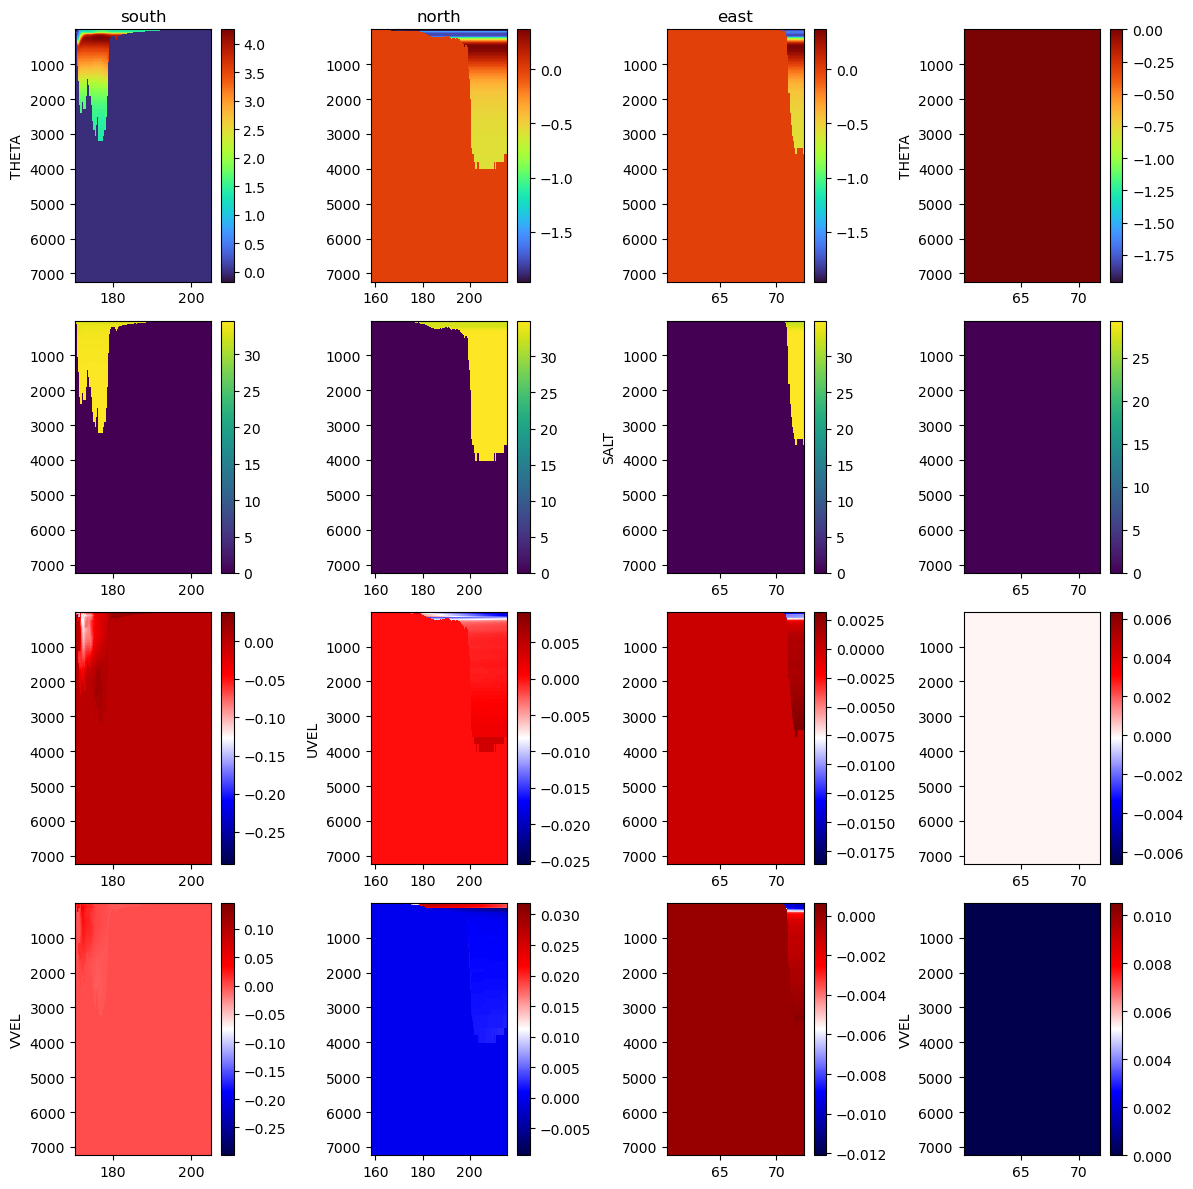

In [47]:
fig = plt.figure(figsize=(12,12))
plot_year = 2022
Z = np.cumsum(delR)
plot_counter = 0
variable_names=var_names[:4]
timesteps=365
for i in range(len(variable_names)):
    variable_name = variable_names[i]
    
    for boundary in boundary_list:
        
        boundary_grid = np.fromfile(os.path.join(input_dir,'obcs','L1_BC_'+boundary+'_'+variable_name+'_'+str(plot_year)),'>f4')
    
        if boundary in ['west','east']:
            boundary_grid = boundary_grid.reshape((timesteps, np.shape(delR)[0],np.shape(XC)[0]))
            boundary_grid = boundary_grid[0, :, :] # choose just the first timestep for plotting
            if boundary=='west':
                x = YC[:,1]
            if boundary=='east':
                x = YC[:,-1]
        else:
            boundary_grid = boundary_grid.reshape((timesteps, np.shape(delR)[0],np.shape(XC)[1]))
            boundary_grid = boundary_grid[0, :, :] # choose just the first timestep for plotting
            if boundary=='north':
                x = XC[-1,:]
            if boundary=='south':
                x = XC[1,:]

        plot_counter += 1
        plt.subplot(len(variable_names),len(boundary_list),plot_counter)
        C = plt.pcolormesh(x, Z, boundary_grid,
                           #vmin=meta_dict[variable_names[i]][0],
                           #vmax=meta_dict[variable_names[i]][1],
                           cmap=meta_dict[variable_names[i]][2])
        plt.colorbar(C,fraction=0.26)
        plt.gca().invert_yaxis()
    
        if plot_counter%3==1:
            plt.ylabel(variable_name)
        if plot_counter<4:
            plt.title(boundary)

plt.tight_layout()

plt.show()

Looks good! Now, with the initial conditions, external forcing conditions, and boundary conditions we are nearly ready to start testing the model!